Device: mps
Params per model: 4,417   (total: 8,834)

  Epoch |    Loss-Ω₁ |    Loss-Ω₂ |   L2-err |       Max |      Mean |  Elapsed
───────────────────────────────────────────────────────────────────────────────
    500 [warm] |   3.34e+00 |   8.75e+00 |   0.0524 |  9.12e-02 |  1.74e-02 |     7.6s
   1000 [warm] |   4.55e-01 |   1.59e+00 |   0.0308 |  4.85e-02 |  1.02e-02 |    14.0s
   1500 [coup] |   1.72e-01 |   1.39e-01 |   0.0400 |  5.78e-02 |  1.44e-02 |    21.9s
   2000 [coup] |   5.59e-02 |   6.41e-02 |   0.0370 |  5.10e-02 |  1.37e-02 |    29.7s
   2500 [coup] |   1.19e-02 |   3.62e-02 |   0.0320 |  4.37e-02 |  1.18e-02 |    37.4s
   3000 [coup] |   5.57e-03 |   2.07e-02 |   0.0294 |  4.05e-02 |  1.08e-02 |    45.3s
   3500 [coup] |   3.20e-03 |   1.13e-02 |   0.0264 |  3.66e-02 |  9.69e-03 |    53.0s
   4000 [coup] |   2.15e-03 |   6.56e-03 |   0.0245 |  3.40e-02 |  8.99e-03 |    60.9s
   4500 [coup] |   1.58e-03 |   4.32e-03 |   0.0233 |  3.25e-02 |  8.57e-03 |    68.6s
   

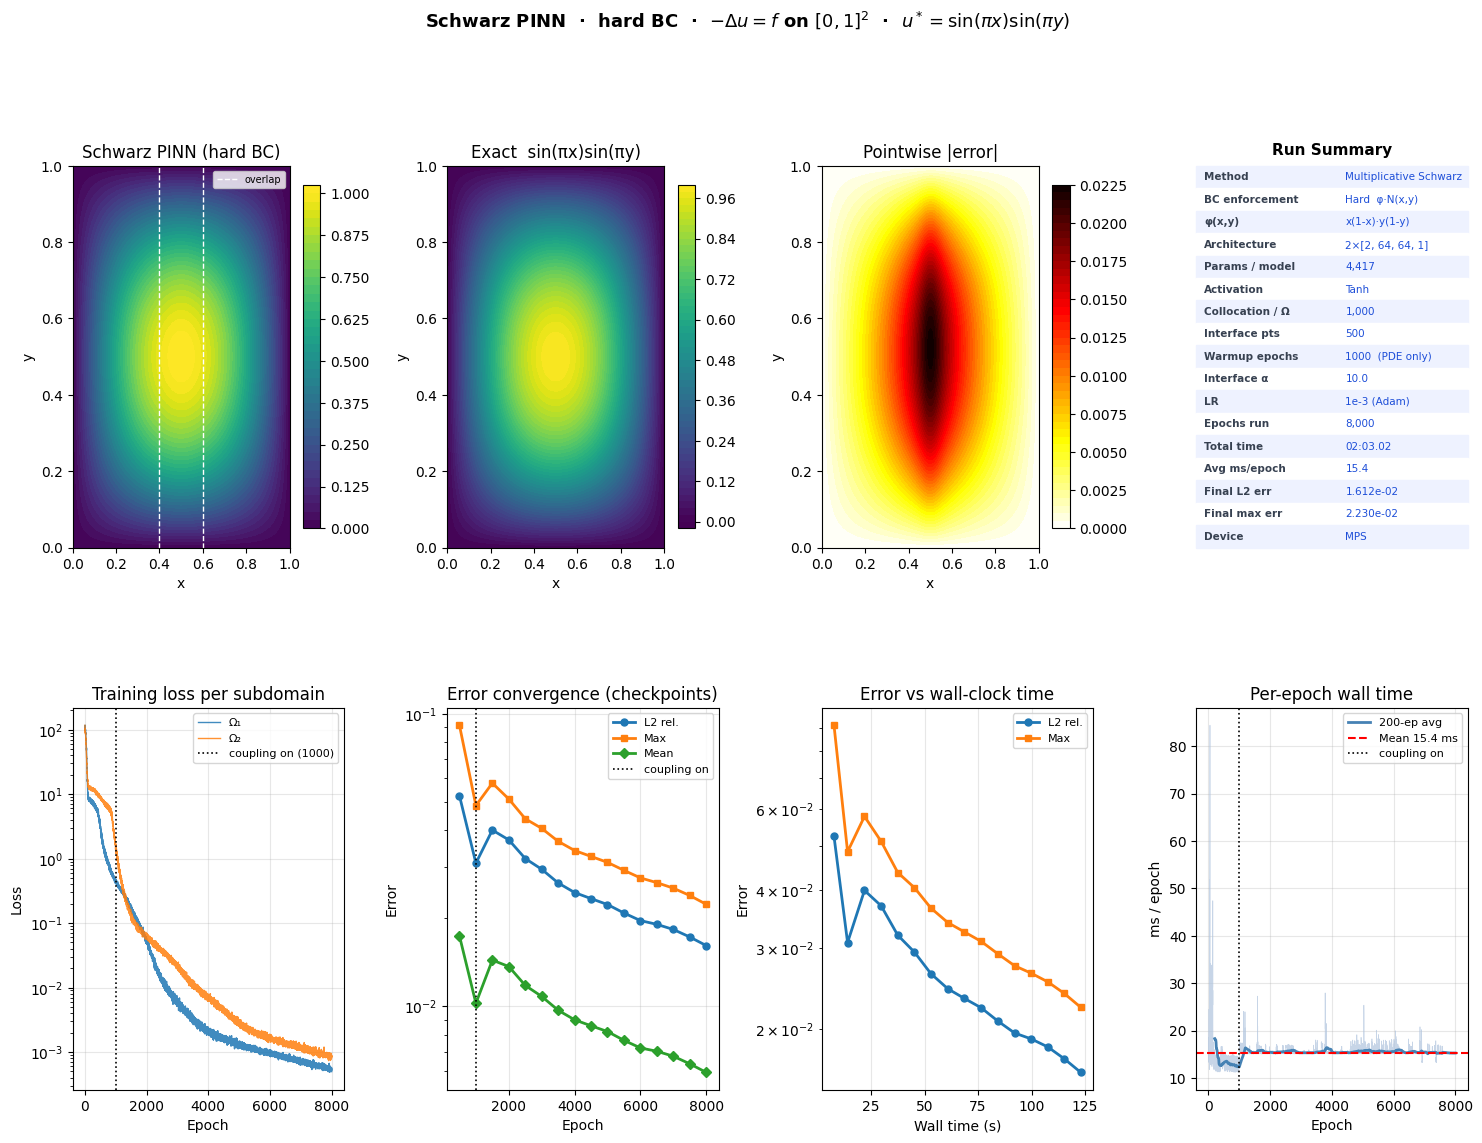

Plot saved → schwarz_pinn_hard_bc.png


In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time

torch.manual_seed(42)
np.random.seed(42)

# ── Device ────────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    torch.mps.manual_seed(42)
else:
    device = torch.device("cpu")
print(f"Device: {device}")


# ── Model ─────────────────────────────────────────────────────────────────────
# Each subdomain needs enough capacity to represent the solution well
# BEFORE the interface coupling kicks in.  [2, 64,  64, 64, 1] ~= 1100 params
# per model — modest but adequate for this smooth solution.
#
# Hard BC:  u = φ · N(x,y),  φ = x(1-x)·y(1-y)  → zero on ∂[0,1]² exactly.
# ─────────────────────────────────────────────────────────────────────────────
class HardBCPINN(nn.Module):
    def __init__(self, layers=[2, 64, 64, 1]):
        super().__init__()
        net = []
        for i in range(len(layers) - 1):
            net.append(nn.Linear(layers[i], layers[i + 1]))
            if i < len(layers) - 2:
                net.append(nn.Tanh())
        self.net = nn.Sequential(*net)
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x, y):
        phi = x * (1.0 - x) * y * (1.0 - y)
        return phi * self.net(torch.cat([x, y], dim=1))


# ── PDE helpers ───────────────────────────────────────────────────────────────
def u_exact(x, y):
    pi = torch.tensor(torch.pi, device=x.device)
    return torch.sin(pi * x) * torch.sin(pi * y)


def pde_residual(model, x, y):
    u    = model(x, y)
    u_x  = torch.autograd.grad(u,   x, grad_outputs=torch.ones_like(u),
                                create_graph=True, retain_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x),
                                create_graph=True, retain_graph=True)[0]
    u_y  = torch.autograd.grad(u,   y, grad_outputs=torch.ones_like(u),
                                create_graph=True, retain_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, grad_outputs=torch.ones_like(u_y),
                                create_graph=True, retain_graph=True)[0]
    pi = torch.tensor(torch.pi, device=x.device)
    f  = -2.0 * pi**2 * torch.sin(pi * x) * torch.sin(pi * y)
    return u_xx + u_yy - f


# ── Sampling ──────────────────────────────────────────────────────────────────
def sample_interior(N, x_min, x_max):
    pts = torch.rand(N, 2, device=device)
    x   = (x_min + (x_max - x_min) * pts[:, 0:1]).requires_grad_(True)
    y   = pts[:, 1:2].requires_grad_(True)
    return x, y


def sample_interface(N=500):
    pts = torch.rand(N, 2, device=device)
    x   = 0.4 + 0.2 * pts[:, 0:1]
    y   = pts[:, 1:2]
    return x, y


# ── Interface loss ────────────────────────────────────────────────────────────
# Gradients flow into `student` only; teacher frozen via no_grad.
def interface_loss(student, teacher, N=500):
    x, y = sample_interface(N)
    with torch.no_grad():
        u_ref = teacher(x, y)
    return torch.mean((student(x, y) - u_ref) ** 2)


# ── Metrics ───────────────────────────────────────────────────────────────────
@torch.no_grad()
def compute_metrics(m1, m2, N=200):
    lin    = torch.linspace(0, 1, N, device=device)
    X, Y   = torch.meshgrid(lin, lin, indexing='ij')
    xf, yf = X.reshape(-1, 1), Y.reshape(-1, 1)
    w      = torch.sigmoid(50.0 * (xf - 0.5))
    u_pred = (1.0 - w) * m1(xf, yf) + w * m2(xf, yf)
    u_true = u_exact(xf, yf)
    l2       = (torch.norm(u_pred - u_true) / torch.norm(u_true)).item()
    max_err  = torch.max(torch.abs(u_pred - u_true)).item()
    mean_err = torch.mean(torch.abs(u_pred - u_true)).item()
    return l2, max_err, mean_err


# ── Training ──────────────────────────────────────────────────────────────────
# Two-phase strategy:
#   Phase 1 (epochs 1..warmup): PDE loss only — each model learns independently.
#     No interface coupling yet, so they aren't chasing each other's noise.
#   Phase 2 (epochs warmup+1..end): PDE + interface loss with weight alpha.
#     By now both models are decent approximations, so the coupling refines
#     the interface region rather than fighting a poorly-initialized teacher.
# ─────────────────────────────────────────────────────────────────────────────
def train_schwarz(m1, m2,
                  epochs=5000,
                  N_int=1000,       # collocation pts per subdomain — match vanilla density
                  lr=1e-3,
                  log_every=500,
                  alpha=10.0,       # interface weight (lower than before — PDE loss is larger now)
                  warmup=500,       # epochs of PDE-only before coupling switches on
                  stop_l2=1e-3,
                  stop_loss=1e-6,
                  patience=3):

    opt1 = torch.optim.Adam(m1.parameters(), lr=lr)
    opt2 = torch.optim.Adam(m2.parameters(), lr=lr)

    hist    = dict(loss1=[], loss2=[], l2=[], max_err=[],
                   mean_err=[], cum_time=[], epoch_ms=[])
    pat_cnt = 0
    t0      = time.perf_counter()

    hdr = (f"{'Epoch':>7} | {'Loss-Ω₁':>10} | {'Loss-Ω₂':>10} | "
           f"{'L2-err':>8} | {'Max':>9} | {'Mean':>9} | {'Elapsed':>8}")
    print(hdr)
    print("─" * len(hdr))

    for ep in range(1, epochs + 1):
        t_ep = time.perf_counter()
        m1.train(); m2.train()

        coupled = ep > warmup   # interface coupling active?

        # ── Step A: update m1 (m2 frozen) ────────────────────────────────
        x1, y1 = sample_interior(N_int, 0.0, 0.6)
        pde1   = torch.mean(pde_residual(m1, x1, y1) ** 2)
        loss1  = pde1
        if coupled:
            loss1 = loss1 + alpha * interface_loss(student=m1, teacher=m2)
        opt1.zero_grad(); loss1.backward(); opt1.step()

        # ── Step B: update m2 (m1 frozen, fresh weights from Step A) ─────
        x2, y2 = sample_interior(N_int, 0.4, 1.0)
        pde2   = torch.mean(pde_residual(m2, x2, y2) ** 2)
        loss2  = pde2
        if coupled:
            loss2 = loss2 + alpha * interface_loss(student=m2, teacher=m1)
        opt2.zero_grad(); loss2.backward(); opt2.step()

        hist["loss1"].append(loss1.item())
        hist["loss2"].append(loss2.item())
        hist["epoch_ms"].append((time.perf_counter() - t_ep) * 1e3)

        if ep % log_every == 0:
            m1.eval(); m2.eval()
            l2, mx, mn = compute_metrics(m1, m2)
            elapsed = time.perf_counter() - t0
            hist["l2"].append(l2)
            hist["max_err"].append(mx)
            hist["mean_err"].append(mn)
            hist["cum_time"].append(elapsed)

            phase = "warm" if not coupled else "coup"
            print(f"{ep:>7} [{phase}] | {loss1.item():>10.2e} | {loss2.item():>10.2e} | "
                  f"{l2:>8.4f} | {mx:>9.2e} | {mn:>9.2e} | {elapsed:>7.1f}s")

            if l2 < stop_l2 or (loss1.item() < stop_loss and loss2.item() < stop_loss):
                pat_cnt += 1
                if pat_cnt >= patience:
                    print(f"\n  Early stop at epoch {ep} (patience {patience} reached)")
                    break
            else:
                pat_cnt = 0

    hist["final_ep"] = ep
    hist["total"]    = time.perf_counter() - t0
    return hist


# ── Plotting ──────────────────────────────────────────────────────────────────
def plot_results(m1, m2, hist, arch, warmup):
    N   = 200
    lin = torch.linspace(0, 1, N, device=device)
    X, Y = torch.meshgrid(lin, lin, indexing='ij')
    xf, yf = X.reshape(-1, 1), Y.reshape(-1, 1)

    m1.eval(); m2.eval()
    with torch.no_grad():
        w      = torch.sigmoid(50.0 * (xf - 0.5))
        U_pred = ((1.0 - w) * m1(xf, yf) + w * m2(xf, yf)).reshape(N, N).cpu().numpy()
        U_true = u_exact(xf, yf).reshape(N, N).cpu().numpy()
    Err = np.abs(U_pred - U_true)
    Xnp, Ynp = X.cpu().numpy(), Y.cpu().numpy()

    ep_arr  = np.arange(1, len(hist["loss1"]) + 1)
    eval_ep = np.linspace(LOG_EVERY, hist["final_ep"], len(hist["l2"]))
    ep_ms   = np.array(hist["epoch_ms"])

    fig = plt.figure(figsize=(18, 12))
    gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.42, wspace=0.38)

    vmin, vmax = U_true.min(), U_true.max()

    ax1 = fig.add_subplot(gs[0, 0])
    c1  = ax1.contourf(Xnp, Ynp, U_pred, 50, cmap='viridis', vmin=vmin, vmax=vmax)
    plt.colorbar(c1, ax=ax1, shrink=0.9)
    ax1.axvline(0.4, color='w', lw=1, ls='--')
    ax1.axvline(0.6, color='w', lw=1, ls='--', label='overlap')
    ax1.set_title("Schwarz PINN (hard BC)"); ax1.legend(fontsize=7)
    ax1.set_xlabel("x"); ax1.set_ylabel("y")

    ax2 = fig.add_subplot(gs[0, 1])
    c2  = ax2.contourf(Xnp, Ynp, U_true, 50, cmap='viridis', vmin=vmin, vmax=vmax)
    plt.colorbar(c2, ax=ax2, shrink=0.9)
    ax2.set_title("Exact  sin(πx)sin(πy)")
    ax2.set_xlabel("x"); ax2.set_ylabel("y")

    ax3 = fig.add_subplot(gs[0, 2])
    c3  = ax3.contourf(Xnp, Ynp, Err, 50, cmap='hot_r')
    plt.colorbar(c3, ax=ax3, shrink=0.9)
    ax3.set_title("Pointwise |error|")
    ax3.set_xlabel("x"); ax3.set_ylabel("y")

    # ── Summary table ──────────────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[0, 3])
    ax4.axis("off")
    ax4.set_title("Run Summary", fontsize=11, fontweight='bold', pad=8)

    mins, secs = divmod(hist["total"], 60)
    p1 = sum(p.numel() for p in m1.parameters())
    rows = [
        ("Method",           "Multiplicative Schwarz"),
        ("BC enforcement",   "Hard  φ·N(x,y)"),
        ("φ(x,y)",           "x(1-x)·y(1-y)"),
        ("Architecture",     arch),
        ("Params / model",   f"{p1:,}"),
        ("Activation",       "Tanh"),
        ("Collocation / Ω",  "1,000"),
        ("Interface pts",    "500"),
        ("Warmup epochs",    f"{warmup}  (PDE only)"),
        ("Interface α",      "10.0"),
        ("LR",               "1e-3 (Adam)"),
        ("Epochs run",       f"{hist['final_ep']:,}"),
        ("Total time",       f"{int(mins):02d}:{secs:05.2f}"),
        ("Avg ms/epoch",     f"{ep_ms.mean():.1f}"),
        ("Final L2 err",     f"{hist['l2'][-1]:.3e}"),
        ("Final max err",    f"{hist['max_err'][-1]:.3e}"),
        ("Device",           str(device).upper()),
    ]
    n = len(rows)
    for k, (label, val) in enumerate(rows):
        y_pos = 1.0 - (k + 0.5) / n
        bg    = '#EEF2FF' if k % 2 == 0 else '#FFFFFF'
        ax4.add_patch(plt.Rectangle(
            (0, 1.0 - (k + 1) / n), 1.0, 1.0 / n,
            transform=ax4.transAxes, color=bg, zorder=0, clip_on=False
        ))
        ax4.text(0.03, y_pos, label, transform=ax4.transAxes,
                 fontsize=7.5, va='center', color='#374151', fontweight='bold')
        ax4.text(0.55, y_pos, val,   transform=ax4.transAxes,
                 fontsize=7.5, va='center', color='#1D4ED8')
    ax4.set_xlim(0, 1); ax4.set_ylim(0, 1)
    for sp in ax4.spines.values():
        sp.set_visible(False)

    # ── Loss curves ────────────────────────────────────────────────────────
    ax5 = fig.add_subplot(gs[1, 0])
    ax5.semilogy(ep_arr, hist["loss1"], lw=1.0, alpha=0.85, label="Ω₁")
    ax5.semilogy(ep_arr, hist["loss2"], lw=1.0, alpha=0.85, label="Ω₂")
    ax5.axvline(warmup, color='k', lw=1.2, ls=':', label=f'coupling on ({warmup})')
    ax5.set_xlabel("Epoch"); ax5.set_ylabel("Loss")
    ax5.set_title("Training loss per subdomain")
    ax5.legend(fontsize=8); ax5.grid(True, alpha=0.3)

    ax6 = fig.add_subplot(gs[1, 1])
    ax6.semilogy(eval_ep, hist["l2"],       'o-', lw=2, ms=5, label="L2 rel.")
    ax6.semilogy(eval_ep, hist["max_err"],  's-', lw=2, ms=5, label="Max")
    ax6.semilogy(eval_ep, hist["mean_err"], 'D-', lw=2, ms=5, label="Mean")
    ax6.axvline(warmup, color='k', lw=1.2, ls=':', label=f'coupling on')
    ax6.set_xlabel("Epoch"); ax6.set_ylabel("Error")
    ax6.set_title("Error convergence (checkpoints)")
    ax6.legend(fontsize=8); ax6.grid(True, alpha=0.3)

    ax7 = fig.add_subplot(gs[1, 2])
    ax7.semilogy(hist["cum_time"], hist["l2"],      'o-', lw=2, ms=5, label="L2 rel.")
    ax7.semilogy(hist["cum_time"], hist["max_err"], 's-', lw=2, ms=5, label="Max")
    ax7.set_xlabel("Wall time (s)"); ax7.set_ylabel("Error")
    ax7.set_title("Error vs wall-clock time")
    ax7.legend(fontsize=8); ax7.grid(True, alpha=0.3)

    ax8 = fig.add_subplot(gs[1, 3])
    ax8.plot(ep_arr, ep_ms, lw=0.5, color='lightsteelblue', alpha=0.7)
    win = min(200, max(1, len(ep_ms) // 5))
    if win > 1:
        sm = np.convolve(ep_ms, np.ones(win) / win, mode='valid')
        ax8.plot(np.arange(win, len(ep_ms) + 1), sm,
                 lw=2.0, color='steelblue', label=f'{win}-ep avg')
    ax8.axhline(ep_ms.mean(), color='red', lw=1.5, ls='--',
                label=f'Mean {ep_ms.mean():.1f} ms')
    ax8.axvline(warmup, color='k', lw=1.2, ls=':', label='coupling on')
    ax8.set_xlabel("Epoch"); ax8.set_ylabel("ms / epoch")
    ax8.set_title("Per-epoch wall time")
    ax8.legend(fontsize=8); ax8.grid(True, alpha=0.3)

    fig.suptitle(
        r"Schwarz PINN  ·  hard BC  ·  $-\Delta u = f$ on $[0,1]^2$  "
        r"·  $u^* = \sin(\pi x)\sin(\pi y)$",
        fontsize=13, fontweight='bold', y=1.01
    )
    out = "schwarz_pinn_hard_bc.png"
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Plot saved → {out}")


# ── Run ───────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    ARCH      = [2, 64,64, 1]   # third layer added
    WARMUP    = 1000                  # longer warmup to match deeper net
    LOG_EVERY = 500

    m1 = HardBCPINN(ARCH).to(device)
    m2 = HardBCPINN(ARCH).to(device)

    p = sum(p.numel() for p in m1.parameters())
    print(f"Params per model: {p:,}   (total: {2*p:,})\n")

    hist = train_schwarz(
        m1, m2,
        epochs    = 8000,             # loss wasn't converged at 5000
        N_int     = 1000,
        lr        = 1e-3,
        log_every = LOG_EVERY,
        alpha     = 10.0,
        warmup    = WARMUP,
        stop_l2   = 1e-3,
        stop_loss = 1e-6,
        patience  = 3,
    )

    print(f"\nFinal L2 error  : {hist['l2'][-1]:.4e}")
    print(f"Final mean error: {hist['mean_err'][-1]:.4e}")
    print(f"Total time      : {hist['total']:.1f}s")

    plot_results(m1, m2, hist, arch=f"2×{ARCH}", warmup=WARMUP)